# Concentration Response Analysis

This notebook analyzes concentration-dependent neural responses using K-means clustering.

**Analysis Workflow:**
1. Load data and select odorant
2. Perform K-means clustering (automated)
3. **VIEW concentration curves** and identify response patterns
4. **⚠️ MANUAL STEP:** Assign cluster IDs to response types
5. Generate final visualizations with meaningful names
6. Save results

**Response Types:**
- **Steep-Ramping**: Sharp increase with concentration
- **High-threshold**: Only responds at highest concentration  
- **Shallow-Ramping**: Gradual increase across concentrations
- **Low-threshold**: Responds at all concentrations

## 1. Configuration and Parameters

In [1]:
# ============================================================================
# FILE PATHS - Modify these for your system
# ============================================================================

# Input files
REF_BRAIN_PATH = '/Volumes/LaCie/area_masks/T_AVG_HuC.tif'
REGRESSION_DATA_PATH = '/Volumes/LaCie/larval_HuC/imaging/regression_results/7dpf_combined_stimulus_response_sustained_25s_correlations.csv'
RESPONSE_VECTOR_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_wb_population_general_response_vector.h5'

# Output directory for figures (CHANGE THIS TO YOUR PATH!)
FIGURE_OUTPUT_DIR = '/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/'

In [2]:
# ============================================================================
# ODORANT DEFINITIONS
# ============================================================================

ODORANT_CONCENTRATIONS = {
    'quinine': {
        'stimuli': ['qui_25um', 'qui_250um', 'qui_2.5mm'],
        'labels': ['Qui 25µM', 'Qui 250µM', 'Qui 2.5mM'],
        'short_name': 'qui'
    },
    'cadaverine': {
        'stimuli': ['cad_25um', 'cad_250um', 'cad_2.5mm'],
        'labels': ['Cad 25µM', 'Cad 250µM', 'Cad 2.5mM'],
        'short_name': 'cad'
    },
    'proline': {
        'stimuli': ['pro_25um', 'pro_250um', 'pro_2.5mm'],
        'labels': ['Pro 25µM', 'Pro 250µM', 'Pro 2.5mM'],
        'short_name': 'pro'
    },
    'food': {
        'stimuli': ['fex_3', 'fex_2', 'fex_1'],
        'labels': ['Fex 1:1000', 'Fex 1:100', 'Fex 1:10'],
        'short_name': 'fex'
    }
}

# Select which odorant to analyze
CURRENT_ODORANT = 'quinine'  # Change to 'cadaverine' or 'proline' as needed


In [3]:
# ============================================================================
# ANALYSIS PARAMETERS
# ============================================================================

# K-means clustering
N_CLUSTERS = 4  # Number of clusters
RANDOM_STATE = 42  # For reproducibility
CLUSTER_RANGE = range(2, 6)  # Range for silhouette analysis

# Brain projection visualization
DOWNSAMPLING_FACTOR = 10  # Downsample coordinates for plotting
SCATTER_SIZE = 10  # Point size in scatter plots
SCATTER_ALPHA = 0.6  # Point transparency
SCALE_BAR_Y = 20  # Scale bar Y position  
SCALE_BAR_XMIN = 20  # Scale bar start X
SCALE_BAR_XMAX = 120  # Scale bar end X

# Cluster colors (consistent across odorants)
CLUSTER_COLORS = {
    "Steep-Ramping": "#FFDF00",      # yellow
    "High-threshold": "#3b528b",     # blue
    "Shallow-Ramping": "#440154",    # dark purple
    "Low-threshold": "#21908d"       # teal
}

In [4]:
# ============================================================================# ANALYSIS PARAMETERS# ============================================================================# K-means clusteringN_CLUSTERS = 4  # Number of clustersRANDOM_STATE = 42  # For reproducibilityCLUSTER_RANGE = range(2, 6)  # Range for silhouette analysis# Brain projection visualizationDOWNSAMPLING_FACTOR = 1  # Downsample factor (1 = plot all neurons)SCATTER_SIZE = 10  # Point size in scatter plotsSCATTER_ALPHA = 0.6  # Point transparencySCALE_BAR_Y = 20  # Scale bar Y position  SCALE_BAR_XMIN = 20  # Scale bar start XSCALE_BAR_XMAX = 120  # Scale bar end X# Cluster colors (consistent across odorants)CLUSTER_COLORS = {    "Steep-Ramping": "#FFDF00",      # yellow    "High-threshold": "#3b528b",     # blue    "Shallow-Ramping": "#440154",    # dark purple    "Low-threshold": "#21908d"       # teal}

## 2. Import Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from skimage import io
import pickle
import json
from ast import literal_eval

from scipy.signal import convolve, resample
from scipy.stats import pearsonr
from scipy import stats
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler, MinMaxScaler, minmax_scale
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.stats.multitest import multipletests

import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 3. Load Data

Load reference brain, regression results, and response vectors.

In [6]:
# Load reference brain for projections
print("Loading reference brain...")
ref_brain = io.imread(REF_BRAIN_PATH)
print(f"Reference brain shape: {ref_brain.shape}")

Loading reference brain...
Reference brain shape: (359, 974, 597)


In [7]:
# Load regression results
print("\nLoading regression results...")
regress = pd.read_csv(REGRESSION_DATA_PATH)
print(f"Regression data: {len(regress)} rows")


Loading regression results...
Regression data: 200116 rows


In [8]:
# Load response vectors
print("\nLoading response vectors...")
data_resp = pd.read_hdf(RESPONSE_VECTOR_PATH)
data_resp['coords'] = data_resp['coords_serialised']
print(f"Response data: {len(data_resp)} rows")
print(f"Unique neurons: {data_resp['neuron_id'].nunique()}")


Loading response vectors...
Response data: 9005220 rows
Unique neurons: 25825


## 4. Core Analysis Functions

Functions for data preparation, clustering, and naming.

In [9]:
def prepare_concentration_data(data, odorant_config, regression_data=None,
                               correlation_threshold=0.3):
    """Filter and prepare concentration-response data.
    
    CRITICAL: Filters neurons by correlation with highest concentration (r >= 0.3)
    
    Args:
        data: Full response DataFrame
        odorant_config: Dict with 'stimuli', 'labels', 'short_name'
        regression_data: Regression results with odorant-specific correlations
        correlation_threshold: Minimum r value to include neuron (default: 0.3)
        
    Returns:
        pivot_df: Wide-format DataFrame (neurons × concentrations)
        averaged_responses: Long-format DataFrame with coordinates
    """
    stimuli = odorant_config['stimuli']
    short_name = odorant_config['short_name']
    
    print(f"\nPreparing data for {stimuli}")
    
    # Apply correlation filter if regression data provided
    if regression_data is not None:
        # Construct correlation column name (e.g., 'qui_2.5mm_correlation')
        # Use the highest concentration (last in list)
        highest_conc = stimuli[-1]  # e.g., 'qui_2.5mm'
        corr_column = f'{highest_conc}_correlation'
        
        if corr_column in regression_data.columns:
            # Filter for strong correlations
            stim_columns = regression_data[[corr_column, 'coords', 'area']]
            filtered_reg = stim_columns[
                stim_columns[corr_column] >= correlation_threshold
            ]
            
            print(f"  Correlation filter ({corr_column} >= {correlation_threshold}):")
            print(f"    Before: {len(regression_data)} neurons")
            print(f"    After: {len(filtered_reg)} neurons")
            
            # Merge with response data
            data_filtered = pd.merge(
                filtered_reg, 
                data, 
                on=['area', 'coords'], 
                how='inner'
            )
        else:
            print(f"  Warning: Correlation column '{corr_column}' not found")
            data_filtered = data.copy()
    else:
        print("  No regression data - skipping correlation filter")
        data_filtered = data.copy()
    
    # Filter for this odorant's stimuli
    data_filtered = data_filtered[data_filtered['stimulus'].isin(stimuli)].copy()
    
    print(f"  Filtered for concentrations: {len(data_filtered)} recordings")
    
    # Average across trials per neuron
    averaged_responses = (
        data_filtered
        .groupby(['fish_id', 'neuron_id', 'stimulus', 'coords', 'area'])['resp']
        .mean()
        .reset_index()
    )
    
    # Make stimulus categorical with correct order
    averaged_responses['stimulus'] = pd.Categorical(
        averaged_responses['stimulus'],
        categories=stimuli,
        ordered=True
    )
    averaged_responses = averaged_responses.sort_values(['fish_id', 'neuron_id', 'stimulus'])
    
    # Pivot to wide format
    pivot_df = averaged_responses.pivot_table(
        index=['fish_id', 'neuron_id', 'area'],
        columns='stimulus',
        values='resp'
    ).reset_index()
    
    # Drop rows with any NaN
    pivot_df = pivot_df.dropna(subset=stimuli)
    
    print(f"  Final neuron count: {len(pivot_df)} neurons with all concentrations")
    
    return pivot_df, averaged_responses


In [10]:
def perform_clustering(pivot_df, stimuli, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE):
    """Perform K-means clustering on concentration responses.
    
    Args:
        pivot_df: Wide-format DataFrame
        stimuli: List of stimulus columns to use
        n_clusters: Number of clusters
        random_state: Random seed
        
    Returns:
        pivot_df: DataFrame with added 'cluster' column
        kmeans: Fitted KMeans object
        scaled_data: Scaled response data
    """
    # Extract response data
    response_data = pivot_df[stimuli].values
    
    # Scale data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(response_data)
    
    # Perform K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    pivot_df['cluster'] = kmeans.fit_predict(scaled_data)
    
    print(f"\nClustering complete: {n_clusters} clusters")
    print(f"Cluster sizes: {pivot_df['cluster'].value_counts().sort_index().to_dict()}")
    
    return pivot_df, kmeans, scaled_data

In [11]:
def assign_cluster_names(pivot_df, cluster_name_map):
    """Assign meaningful names to clusters.
    
    Args:
        pivot_df: DataFrame with 'cluster' column
        cluster_name_map: Dict mapping cluster ID to name
        
    Returns:
        pivot_df: DataFrame with 'response_condition' column
    """
    # Validate all clusters are mapped
    unique_clusters = set(pivot_df['cluster'].unique())
    mapped_clusters = set(cluster_name_map.keys())
    
    if unique_clusters != mapped_clusters:
        missing = unique_clusters - mapped_clusters
        raise ValueError(
            f"Not all clusters are mapped! Missing clusters: {missing}\n"
            f"Please update cluster_name_map to include all cluster IDs."
        )
    
    # Apply mapping
    pivot_df['response_condition'] = pivot_df['cluster'].map(cluster_name_map)
    
    print("\nCluster names assigned:")
    for cluster_id, name in cluster_name_map.items():
        count = len(pivot_df[pivot_df['cluster'] == cluster_id])
        print(f"  Cluster {cluster_id} → {name}: {count} neurons")
    
    return pivot_df

In [12]:
def calculate_response_fractions(pivot_df, cluster_order=None):
    """Calculate fraction of neurons in each response type.
    
    Args:
        pivot_df: DataFrame with 'response_condition' column
        cluster_order: Optional list specifying order for plotting
        
    Returns:
        fractions_df: DataFrame with counts and fractions per response type
    """
    counts = pivot_df['response_condition'].value_counts()
    total = len(pivot_df)
    fractions = counts / total
    
    fractions_df = pd.DataFrame({
        'response_condition': counts.index,
        'count': counts.values,
        'fraction': fractions.values
    })
    
    if cluster_order:
        fractions_df['response_condition'] = pd.Categorical(
            fractions_df['response_condition'],
            categories=cluster_order,
            ordered=True
        )
        fractions_df = fractions_df.sort_values('response_condition')
    
    return fractions_df

In [13]:
def merge_coordinates(pivot_df, averaged_responses):
    """Merge coordinate information back to clustered data.
    
    Args:
        pivot_df: DataFrame with cluster assignments
        averaged_responses: DataFrame with coordinate information
        
    Returns:
        pivot_df: DataFrame with added 'coords' column
    """
    # Extract unique coords per neuron
    coords_df = averaged_responses[['fish_id', 'neuron_id', 'coords']].drop_duplicates()
    
    # Merge
    pivot_df = pivot_df.merge(coords_df, on=['fish_id', 'neuron_id'], how='left')
    
    print(f"\nMerged coordinates for {len(pivot_df)} neurons")
    
    return pivot_df

## 5. Plotting Functions

Functions for visualization and analysis.

In [14]:
def plot_silhouette_analysis(scaled_data, cluster_range=CLUSTER_RANGE, save_path=None):
    """Plot silhouette scores for different cluster numbers.
    
    Args:
        scaled_data: Scaled response data
        cluster_range: Range of cluster numbers to test
        save_path: Optional path to save figure
        
    Returns:
        fig: matplotlib.figure.Figure
        silhouette_scores: Dict of n_clusters → score
    """
    silhouette_scores = {}
    
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE)
        cluster_labels = kmeans.fit_predict(scaled_data)
        silhouette_avg = silhouette_score(scaled_data, cluster_labels)
        silhouette_scores[n_clusters] = silhouette_avg
    
    # Plot
    fig = plt.figure(figsize=(8, 5))
    plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 
             marker='o', linewidth=2)
    plt.xlabel('Number of Clusters', fontsize=14)
    plt.ylabel('Silhouette Score', fontsize=14)
    plt.title('Silhouette Analysis for Optimal Clusters', fontsize=16)
    plt.grid(alpha=0.3)
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig, silhouette_scores

In [15]:
def plot_concentration_response_curves(pivot_df, stimuli, labels, 
                                       cluster_color_map=None, 
                                       use_cluster_ids=False,
                                       title=None, save_path=None):
    """Plot mean ± STD concentration-response curves per cluster.
    
    Args:
        pivot_df: DataFrame with cluster assignments
        stimuli: List of stimulus columns
        labels: List of stimulus labels for x-axis
        cluster_color_map: Dict mapping response_condition to color (optional)
        use_cluster_ids: If True, use cluster IDs instead of names
        title: Optional plot title
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    fig = plt.figure(figsize=(8, 5))
    
    if use_cluster_ids:
        # Plot with cluster IDs (before naming)
        group_col = 'cluster'
        for cluster_id, group in pivot_df.groupby('cluster'):
            mean_resp = group[stimuli].mean()
            std_resp = group[stimuli].std()
            
            plt.plot(labels, mean_resp, marker='o', linewidth=2,
                    label=f'Cluster {cluster_id}')
            plt.fill_between(range(len(labels)), 
                           mean_resp - std_resp, 
                           mean_resp + std_resp, 
                           alpha=0.2)
    else:
        # Plot with meaningful names (after naming)
        group_col = 'response_condition'
        for condition, group in pivot_df.groupby('response_condition'):
            mean_resp = group[stimuli].mean()
            std_resp = group[stimuli].std()
            
            color = cluster_color_map.get(condition, 'gray') if cluster_color_map else None
            
            plt.plot(labels, mean_resp, marker='o', linewidth=2,
                    label=condition, color=color)
            plt.fill_between(range(len(labels)),
                           mean_resp - std_resp,
                           mean_resp + std_resp,
                           alpha=0.2, color=color)
    
    plt.xlabel('Stimulus Concentration', fontsize=14)
    plt.ylabel('Average Response', fontsize=14)
    
    if title:
        plt.title(title, fontsize=16)
    else:
        plt.title('Concentration-Response Curves', fontsize=16)
    
    plt.legend(loc='best', fontsize=11)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [16]:
def plot_classified_neuron_fractions(pivot_df, cluster_color_map, 
                                    odorant_name='', save_path=None):
    """Plot stacked bar chart showing FB vs HB fraction of neurons per response type.
    
    Args:
        pivot_df: DataFrame with cluster assignments and fish_id
        cluster_color_map: Dict mapping response_condition to color
        odorant_name: Name of odorant for title
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    classified_responses = pivot_df.copy()
    
    # Extract fish type (forebrain vs hindbrain)
    classified_responses['fish_type'] = classified_responses['fish_id'].apply(
        lambda x: '_fb' if '_fb' in x else '_hb'
    )
    
    # Count neurons per fish_type and response condition
    neuron_counts = (
        classified_responses
        .groupby(['fish_type', 'response_condition'])
        .size()
        .reset_index(name='count')
    )
    
    # Normalize to get fractions within each fish_type
    neuron_totals = neuron_counts.groupby('fish_type')['count'].transform('sum')
    neuron_counts['fraction'] = neuron_counts['count'] / neuron_totals
    
    # Pivot for bar plotting
    plot_df = neuron_counts.pivot(
        index='fish_type',
        columns='response_condition',
        values='fraction'
    ).fillna(0)
    
    # Apply custom color order matching columns
    cluster_order = [col for col in plot_df.columns if col in cluster_color_map]
    colors = [cluster_color_map[cluster] for cluster in cluster_order]
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_df[cluster_order].plot(kind='bar', stacked=True, color=colors, ax=ax)
    
    # Formatting
    plt.ylabel('Fraction of Classified Neurons', fontsize=20)
    plt.xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Forebrain', 'Hindbrain'], fontsize=20, rotation=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=2)
    ax.tick_params(axis='both', which='major', labelsize=22)
    
    if odorant_name:
        plt.title(odorant_name, ha='right', fontsize=20, weight='bold')
    
    # Legend
    ax.legend(
        title='Response Type',
        title_fontsize=16,
        fontsize=14,
        loc='upper left',
        bbox_to_anchor=(1, 1),
        labels=cluster_order,
        frameon=False
    )
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [17]:
def plot_per_fish_fractions(pivot_df, cluster_color_map, save_path=None):
    """Plot stacked bar chart showing response type fractions per individual fish.
    
    Args:
        pivot_df: DataFrame with cluster assignments and fish_id
        cluster_color_map: Dict mapping response_condition to color
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    # Remove suffix from fish_id to get base fish ID
    pivot_df_copy = pivot_df.copy()
    pivot_df_copy["fish_base"] = pivot_df_copy["fish_id"].str.split("_").str[0]
    
    # Count neurons per fish and response condition
    cluster_counts = (
        pivot_df_copy.groupby(["fish_base", "response_condition"])
        .size()
        .reset_index(name="count")
    )
    
    # Pivot so rows = fish, cols = response types
    cluster_pivot = cluster_counts.pivot(
        index="fish_base",
        columns="response_condition",
        values="count"
    ).fillna(0)
    
    # Normalize to fractions per fish
    cluster_prop = cluster_pivot.div(cluster_pivot.sum(axis=1), axis=0)
    
    # Reorder columns to match cluster_color_map
    valid_clusters = [c for c in cluster_color_map if c in cluster_prop.columns]
    cluster_prop = cluster_prop[valid_clusters]
    
    # Build color list
    colors = [cluster_color_map[c] for c in cluster_prop.columns]
    
    # Plot stacked bar with custom colors
    fig, ax = plt.subplots(figsize=(7, 6))
    cluster_prop.plot(
        kind="bar",
        stacked=True,
        color=colors,
        edgecolor="black",
        ax=ax
    )
    
    plt.ylabel("Fraction of Neurons", fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel("Fish ID", fontsize=20, labelpad=10)
    plt.legend('')  # Remove legend
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [18]:
def plot_response_conditions_2view(coords_array, response_conditions, ref_brain,
                                  cluster_color_map,
                                  downsampling=DOWNSAMPLING_FACTOR,
                                  scatter_size=SCATTER_SIZE,
                                  scatter_alpha=SCATTER_ALPHA,
                                  save_path=None):
    """Brain projections showing spatial distribution of response types.
    
    Creates horizontal (top) and sagittal (side) views with color-coded neurons.
    
    Args:
        coords_array: Array of neuron coordinates (N x 3)
        response_conditions: Array of response type labels (N,)
        ref_brain: Reference brain volume
        cluster_color_map: Dict mapping response_condition to color
        downsampling: Downsample factor for plotting
        scatter_size: Point size
        scatter_alpha: Point transparency
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    # Downsample for visualization
    coords = coords_array[::downsampling]
    response_conditions = response_conditions[::downsampling]
    
    unique_conditions = np.unique(response_conditions)
    
    # Create figure with GridSpec
    fig = plt.figure(figsize=(12, 5))
    gs = gridspec.GridSpec(1, 2, figure=fig)
    ax_horizontal = fig.add_subplot(gs[0, 0])
    ax_sagittal = fig.add_subplot(gs[0, 1])
    
    ### Horizontal projection (top view)
    proj_horizontal = np.nanmean(ref_brain, axis=0)
    proj_horizontal = np.rot90(proj_horizontal, k=1)
    ax_horizontal.imshow(proj_horizontal, cmap='gray_r', alpha=0.5, origin='lower')
    
    for condition in unique_conditions:
        color = cluster_color_map.get(condition, 'gray')
        cond_coords = coords[response_conditions == condition]
        ax_horizontal.scatter(
            cond_coords[:, 1],
            proj_horizontal.shape[0] - cond_coords[:, 2],
            c=color, s=scatter_size, edgecolor='none',
            alpha=scatter_alpha, label=condition
        )
    
    ax_horizontal.axis('off')
    ax_horizontal.set_aspect('equal')
    ax_horizontal.set_xlim(0, proj_horizontal.shape[1])
    ax_horizontal.set_ylim(0, proj_horizontal.shape[0])
    
    # Scale bar
    ax_horizontal.hlines(y=proj_horizontal.shape[0] - SCALE_BAR_Y,
                        xmin=SCALE_BAR_XMIN, xmax=SCALE_BAR_XMAX,
                        color='black', linewidth=3)
    
    ### Sagittal projection (side view)
    proj_sagittal = np.nanmean(ref_brain, axis=2)
    ax_sagittal.imshow(proj_sagittal, cmap='gray_r', alpha=0.5, origin='lower')
    
    for condition in unique_conditions:
        color = cluster_color_map.get(condition, 'gray')
        cond_coords = coords[response_conditions == condition]
        ax_sagittal.scatter(
            cond_coords[:, 1], cond_coords[:, 0],
            c=color, s=scatter_size, edgecolor='none',
            alpha=scatter_alpha
        )
    
    ax_sagittal.axis('off')
    ax_sagittal.set_aspect('equal')
    ax_sagittal.set_xlim(0, proj_sagittal.shape[1])
    ax_sagittal.set_ylim(0, proj_sagittal.shape[0])
    
    # Legend
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', label=cond,
                  markerfacecolor=cluster_color_map.get(cond, 'gray'), 
                  markersize=6)
        for cond in unique_conditions
    ]
    fig.legend(handles=handles, loc='upper left', title='Response Type',
              bbox_to_anchor=(0.85, 0.82), frameon=False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

## 6. Analysis Pipeline - STEP 1: Initial Clustering

⚠️ **WORKFLOW:** This analysis requires human input!

1. **Run cells below** to perform clustering
2. **View concentration curves** with cluster IDs (0, 1, 2, 3)
3. **Identify patterns** in each cluster
4. **Proceed to Section 7** to assign meaningful names

In [19]:
# Get configuration for selected odorant
odorant_config = ODORANT_CONCENTRATIONS[CURRENT_ODORANT]
stimuli = odorant_config['stimuli']
labels = odorant_config['labels']
short_name = odorant_config['short_name']

print(f"Analyzing: {CURRENT_ODORANT.upper()}")
print(f"Concentrations: {stimuli}")

Analyzing: QUININE
Concentrations: ['qui_25um', 'qui_250um', 'qui_2.5mm']


In [20]:
# Prepare data
pivot_df, averaged_responses = prepare_concentration_data(
    data_resp, 
    odorant_config,
    regress
)


Preparing data for ['qui_25um', 'qui_250um', 'qui_2.5mm']
  Correlation filter (qui_2.5mm_correlation >= 0.3):
    Before: 200116 neurons
    After: 22525 neurons
  Filtered for concentrations: 202788 recordings
  Final neuron count: 22526 neurons with all concentrations


In [24]:
# Optional: Silhouette analysis to determine optimal n_clusters
# Uncomment to run

# fig_silhouette, scores = plot_silhouette_analysis(scaled_data)
# plt.show()
# print("\nSilhouette scores:")
# for n, score in scores.items():
#     print(f"  {n} clusters: {score:.3f}")

In [21]:
# Perform K-means clustering
pivot_df, kmeans, scaled_data = perform_clustering(
    pivot_df,
    stimuli,
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE
)


Clustering complete: 4 clusters
Cluster sizes: {0: 16407, 1: 403, 2: 2932, 3: 2784}


### 📊 View Concentration-Response Curves

**⚠️ IMPORTANT:** Study this plot carefully!

Identify which cluster ID (0, 1, 2, 3) corresponds to each response pattern:
- **Steep-Ramping**: Sharp increase with concentration
- **High-threshold**: Only responds at highest concentration
- **Shallow-Ramping**: Gradual increase across concentrations  
- **Low-threshold**: Responds at all concentrations

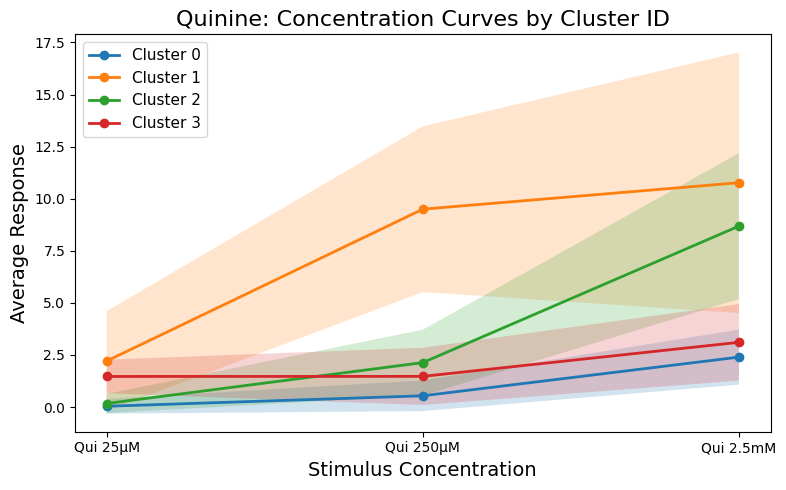


⚠️ NEXT STEP: Go to Section 7 and update cluster_name_map


In [22]:
# Plot concentration curves with CLUSTER IDs (not yet named)
fig_curves_ids = plot_concentration_response_curves(
    pivot_df, 
    stimuli, 
    labels,
    use_cluster_ids=True,
    title=f"{CURRENT_ODORANT.title()}: Concentration Curves by Cluster ID"
)
plt.show()

print("\n" + "="*60)
print("⚠️ NEXT STEP: Go to Section 7 and update cluster_name_map")
print("="*60)

## 7. Analysis Pipeline - STEP 2: Manual Cluster Assignment

⚠️ **EDIT THE CELL BELOW**

Based on the concentration curves you viewed above, assign each cluster ID to a response type.

**Instructions:**
1. Look at the plot above
2. Determine which cluster ID (0, 1, 2, 3) shows which pattern
3. Update the dictionary below with your assignments
4. Run the cell
5. Proceed to Section 8

In [23]:
# ============================================================================
# ⚠️ EDIT THIS CELL - MANUAL CLUSTER ASSIGNMENT
# ============================================================================
#
# Based on the concentration-response curves above, assign each cluster ID
# to a response type.
#
# Response patterns:
# - "Steep-Ramping": Sharp increase with concentration
# - "High-threshold": Only responds at highest concentration
# - "Shallow-Ramping": Gradual increase across concentrations
# - "Low-threshold": Responds at all concentrations
#
# EXAMPLE (from original quinine analysis):

cluster_name_map = {
    1: 'Steep-Ramping',      # ← Which cluster ID shows steep ramping?
    0: 'High-threshold',     # ← Which cluster ID shows high threshold?
    2: 'Shallow-Ramping',    # ← Which cluster ID shows shallow ramping?
    3: 'Low-threshold'       # ← Which cluster ID shows low threshold?
}

# ============================================================================
# After editing, run this cell, then proceed to Section 8
# ============================================================================

print("Cluster name mapping defined:")
for cluster_id, name in cluster_name_map.items():
    print(f"  Cluster {cluster_id} → {name}")

Cluster name mapping defined:
  Cluster 1 → Steep-Ramping
  Cluster 0 → High-threshold
  Cluster 2 → Shallow-Ramping
  Cluster 3 → Low-threshold


### Validate and Apply Names

This cell checks that all clusters are mapped and applies the names.

In [24]:
# ⚠️ Validation check
if 'cluster_name_map' not in locals():
    raise ValueError(
        "⚠️ ERROR: cluster_name_map not defined!\n"
        "Please go back and edit the cell above to define your cluster assignments."
    )

# Apply cluster names
pivot_df = assign_cluster_names(pivot_df, cluster_name_map)

# Merge coordinates
pivot_df = merge_coordinates(pivot_df, averaged_responses)

print("\n✅ Cluster names successfully applied!")
print("Proceed to Section 8 for visualization.")


Cluster names assigned:
  Cluster 1 → Steep-Ramping: 403 neurons
  Cluster 0 → High-threshold: 16407 neurons
  Cluster 2 → Shallow-Ramping: 2932 neurons
  Cluster 3 → Low-threshold: 2784 neurons

Merged coordinates for 22526 neurons

✅ Cluster names successfully applied!
Proceed to Section 8 for visualization.


## 8. Analysis Pipeline - STEP 3: Final Visualization

Generate all final plots with meaningful response type names.

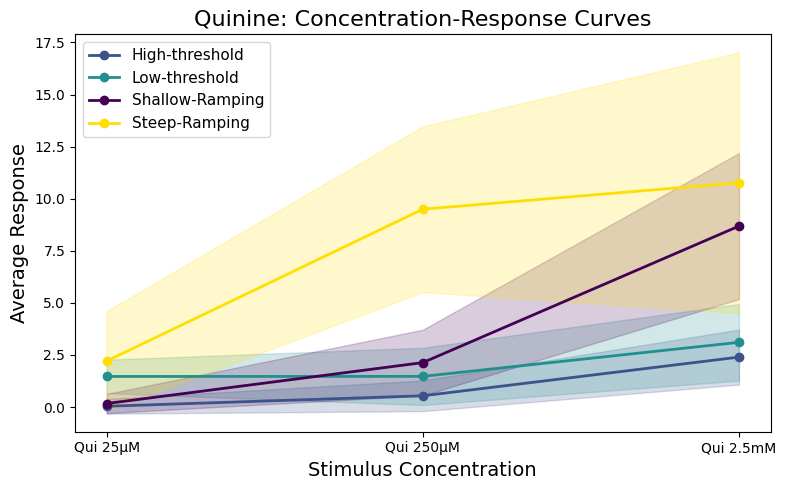

In [29]:
# Plot concentration curves with MEANINGFUL NAMES
fig_curves = plot_concentration_response_curves(
    pivot_df,
    stimuli,
    labels,
    cluster_color_map=CLUSTER_COLORS,
    use_cluster_ids=False,
    title=f"{CURRENT_ODORANT.title()}: Concentration-Response Curves"
)
plt.show()

# Uncomment to save
# save_path = FIGURE_OUTPUT_DIR + f'{short_name}_concentration_curves.svg'
# fig_curves.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

In [30]:
# Calculate neuron fractions
cluster_order = ['Steep-Ramping', 'High-threshold', 'Shallow-Ramping', 'Low-threshold']
fractions_df = calculate_response_fractions(pivot_df, cluster_order)

print("\nNeuron fractions by response type:")
for _, row in fractions_df.iterrows():
    print(f"  {row['response_condition']}: {row['fraction']:.2%} ({row['count']} neurons)")


Neuron fractions by response type:
  Steep-Ramping: 1.79% (403 neurons)
  High-threshold: 72.84% (16407 neurons)
  Shallow-Ramping: 13.02% (2932 neurons)
  Low-threshold: 12.36% (2784 neurons)


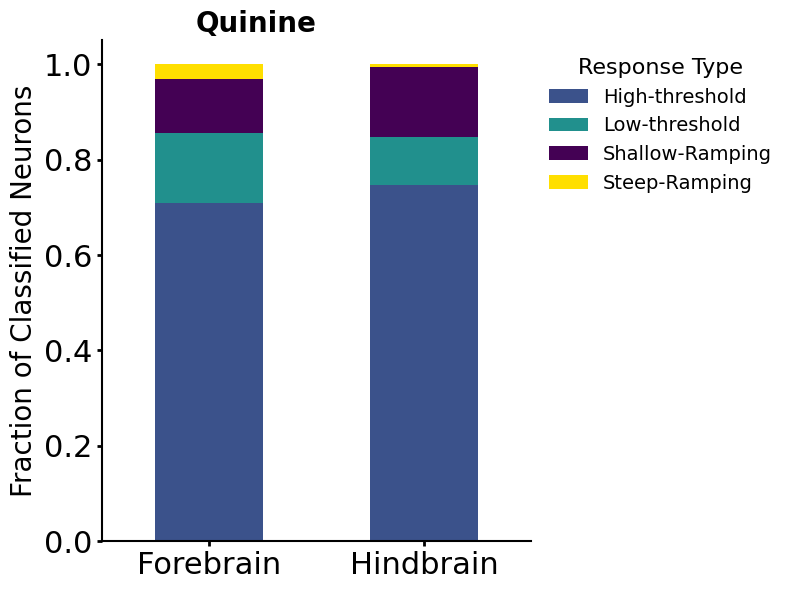

In [31]:
# Plot FB vs HB fraction distribution
fig_fractions_fbhb = plot_classified_neuron_fractions(
    pivot_df,
    CLUSTER_COLORS,
    odorant_name=CURRENT_ODORANT.title()
)
plt.show()

# Uncomment to save
# save_path = FIGURE_OUTPUT_DIR + f'{short_name}_neuron_fractions_fbhb.svg'
# fig_fractions_fbhb.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

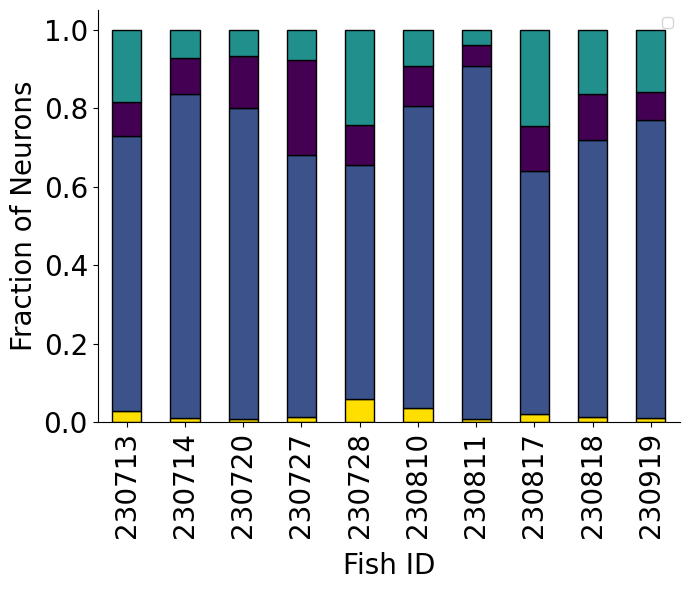

In [32]:
# Plot per-fish fraction distribution
fig_fractions_perfish = plot_per_fish_fractions(
    pivot_df,
    CLUSTER_COLORS
)
plt.show()

# Uncomment to save
# save_path = FIGURE_OUTPUT_DIR + f'{short_name}_cluster_fish_distribution.svg'
# fig_fractions_perfish.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')


Plotting 22526 neurons on brain projections


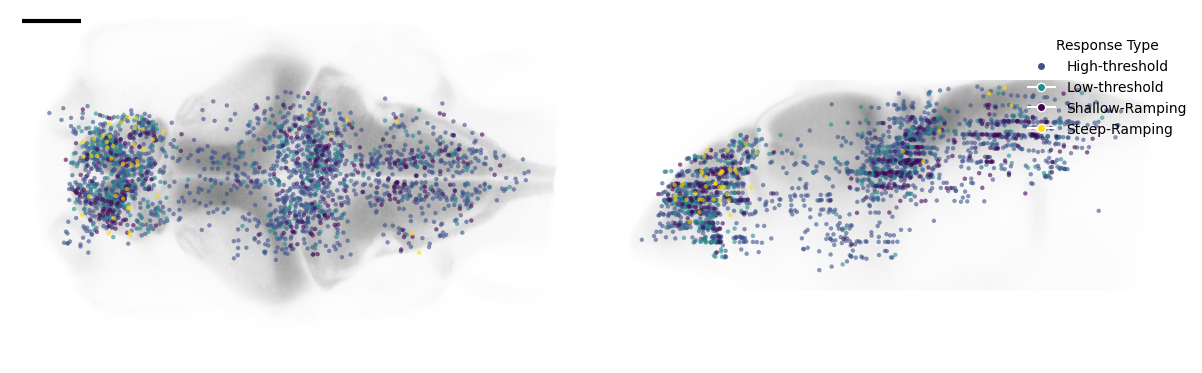

In [35]:
# Prepare brain projection data (plot ALL neurons)
coords_list = [literal_eval(c) if isinstance(c, str) else c 
               for c in pivot_df['coords'].values]
coords_array = np.array(coords_list)
response_array = pivot_df['response_condition'].values

print(f"\nPlotting {len(coords_array)} neurons on brain projections")

# Plot brain projections (all neurons, no downsampling)
fig_brain = plot_response_conditions_2view(
    coords_array,
    response_array,
    ref_brain,
    CLUSTER_COLORS,
    downsampling=10  # Plot every 10th neurons for visual clarity  
)
plt.show()

# Uncomment to save
# save_path = FIGURE_OUTPUT_DIR + f'{short_name}_brain_projections.svg'
# fig_brain.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

In [36]:
# Save classified neuron data
# Uncomment to save

# output_df = pivot_df[['fish_id', 'neuron_id', 'cluster', 'response_condition', 'coords']]
# output_df['odorant'] = short_name
# save_path = FIGURE_OUTPUT_DIR + f'{short_name}_classified_neurons.csv'
# output_df.to_csv(save_path, index=False)
# print(f"\nSaved classified neurons to: {save_path}")

## 9. Analysis Complete!

✅ **Summary:**
- Clustered neurons into response types
- Visualized concentration-response curves
- Analyzed distribution across response types
- Mapped spatial distribution in brain

**To analyze another odorant:**
1. Go to Section 1
2. Change `CURRENT_ODORANT` to 'cadaverine' or 'proline'
3. Run all cells from Section 6 onwards
4. Repeat the manual cluster assignment (Section 7)